In [32]:
# 로지스틱 회귀 구현

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

x = cancer.data
y = cancer.target
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(np.unique(cancer.target, return_counts=True), ": [음성, 양성], [음성갯수, 양성갯수]") # return_counts: 빈도수도 함께 반환

class LogisticNeuron:
    def __init__(self):
        self.w = None
        self.b = None
    
    def forpass(self, x):
        z = np.sum(x * self.w) + self.b
        return z

    def backprob(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad

    
    def fit(self, x, y, epochs=100):
        self.w = np.ones(x.shape[1]) # 1로 초기화된 가중치 리스트
        self.b = 0
        for i in range(epochs):
            for x_i, y_i in zip(x, y):
                z = self.forpass(x_i)
                a = self.activation(z)
                err = -(y_i - a)
                w_grad, b_grad = self.backprob(x_i, err)
                self.w -= w_grad
                self.b -= b_grad

    def activation(self, z): # 시그모이드 함수 사용
        z = np.clip(z, -100, None) # 최소값을 -100, 최댓값은 설정안함(None)  z가 너무 크면 오버플로우 발생
        a = 1/(1+np.exp(-z))
        return a

    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]
        a = self.activation(z)
        return a > 0.5


neuron = LogisticNeuron()
neuron.fit(x_train, y_train)

np.mean(neuron.predict(x_test) == y_test)
 

(array([0, 1]), array([212, 357], dtype=int64)) : [음성, 양성], [음성갯수, 양성갯수]


0.8245614035087719

#### 단일층 신경망
- 일반적으로 신경망은 왼쪽의 입력층(input layer), 오른쪽의 출력층(output layer), 가운데의 은닉층(hidden layer)으로 구성됨.  
    <img src="img/zb.png" alt="image.png" style="width:500px;" />

- 단일층 신경망(single-layer neural network): 은닉층이 없는 신경  
    <img src="img/zc.png" alt="image.png" style="width:500px;" />



#### 확률적 경사 하강법(stochastic gradient descent, SGD)
- 지금까지 사용한 경사 하강법
- 매 반복마다 훈련 세트에서 무작위로 선택된 샘플 하나를 사용하여 그레디언트 계산.(샘플마다 가중치가 조금씩 업데이트됨)  
    <img src="img/zd.png" alt="image.png" style="width:500px;" />

#### 배치 경사 하강법(batch gradient descent)
- 매 반복마다 훈련 세트 전체를 사용하여 그레디언트 계산.(가중치가 샘플들의 평균값으로 업데이트됨)  
    <img src="img/ze.png" alt="image.png" style="width:500px;" />

#### 미니배치 경사 하강법(mini-batch gradient descent)
- 매 반복마다 훈련 세트에서 무작위로 선택된 샘플들의 작은 배치를 사용하여 그레디언트 계산.  
    <img src="img/zf.png" alt="image.png" style="width:500px;" />


#### 확률적 경사 하강법 vs (미니) 배치 경사 하강법
- 확률적 경사 하강법: 계산 비용 낮음, 가중치가 최적값에 수렴하는 과정이 불안정함
- (미니) 배치 경사 하강법: 계산 비용 높음, 가중치가 최적값에 수렴하는 과정이 안정적임  
    <img src="img/zg.png" alt="image.png" style="width:500px;" />


#### 경사 하강법
- 가중치 최적값의 탐색 과정이 다양해저 가중치 최적값을 제대로 찾을 수 있기 때문에 **에포크마다 순서를 섞어야한다**
- `np.random.permutation()` 함수를 사용하여 샘플 순서를 섞을 수 있음. 

(array([0, 1]), array([212, 357], dtype=int64)) : [음성, 양성], [음성갯수, 양성갯수]


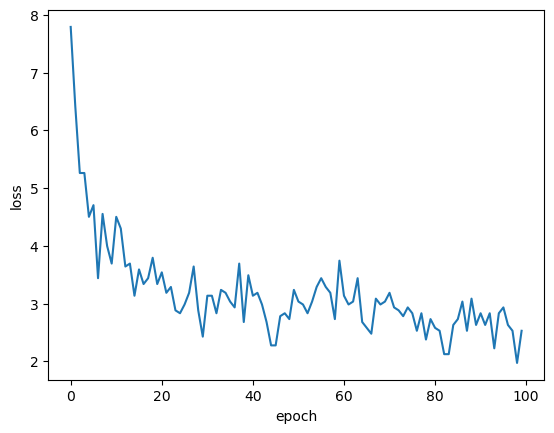

In [31]:
# 손실 함수의 결과값 저장 기능 추가

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

class SingleLayer:
    def __init__(self):
        self.w = None
        self.b = None

        self.losses = []
    
    def forpass(self, x):
        z = np.sum(x * self.w) + self.b
        return z

    def backprob(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad

    
    def activation(self, z): # 시그모이드 함수 사용
        z = np.clip(z, -100, None) # 최소값을 -100, 최댓값은 설정안함(None)  z가 너무 크면 오버플로우 발생
        a = 1/(1+np.exp(-z))
        return a
    
    def fit(self, x, y, epochs=100):
        self.w = np.ones(x.shape[1]) # 1로 초기화된 가중치 리스트
        self.b = 0

        for i in range(epochs):

            loss = 0
            indexes = np.random.permutation(np.arange(len(x))) # 0~(len-1) 까지의 인덱스가 섞인 새로운 배열 반환(suffle은 배열 자체를 바꾼다.)

            for i in indexes: # 모든 샘플에 대해 계산

                z = self.forpass(x[i]) # 정방향 계산
                a = self.activation(z) # 활성화 함수 적용
                err = -(y[i] - a) # 오차 계산
                w_grad, b_grad = self.backprob(x[i], err) # 역방향 계산
                self.w -= w_grad # 가중치 업데이트
                self.b -= b_grad # 절편 업데이트, 모든 샘플에 대해 한번씩 계산하므로 SGD이다. 배치 경사 하강법은 평균값을 반복 이후에 한번만 수정

                a = np.clip(a, 1e-10, 1-1e-10) # 안전한 로그 계산을 위해 클리핑한 후 손실 누적

                loss += -(y[i] * np.log(a) + (1 - y[i]) * np.log(1-a)) # 에포크마다 평균 손실 저장, 로지스틱 손실 함수 사용

            self.losses.append(loss/len(y)) # 평균 손실 추가


    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]
        a = self.activation(z)
        return a > 0.5
    
    def score(self, x, y):
        return np.mean(self.predict(x) == y)
    
cancer = load_breast_cancer()

x = cancer.data
y = cancer.target
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(np.unique(cancer.target, return_counts=True), ": [음성, 양성], [음성갯수, 양성갯수]")  # return_counts: 빈도수도 함께 반환

layer = SingleLayer()
layer.fit(x_train, y_train)
layer.score(x_test, y_test)

plt.plot(layer.losses)
plt.xlabel('epoch') 
plt.ylabel('loss')
plt.show()

In [29]:
# Sci-kit learn 으로 로지스틱 회귀

from sklearn.linear_model import SGDClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

x = cancer.data
y = cancer.target
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(np.unique(cancer.target, return_counts=True), ": [음성, 양성], [음성갯수, 양성갯수]")  # return_counts: 빈도수도 함께 반환


sgd = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-3, random_state=42)
# loss='log_loss': 손실함수를 로지스틱 회귀를 위한 손실함수 선택
# max_iter=100: 100번 반복(에포크)
# tol=1e-3: 학습을 멈출 허용 오차(에포키그 남았어도 이전에 비해 tol보다 더 줄어들지 않으면 조기 학습 중단)
# random_state=42: 데이터를 섞거나 가중치를 초기화할 때 쓸 random seed

sgd.fit(x_train, y_train)
print(sgd.score(x_test, y_test))
print(sgd.predict(x_test[0:10]))

(array([0, 1]), array([212, 357], dtype=int64)) : [음성, 양성], [음성갯수, 양성갯수]
0.8333333333333334
[0 1 0 0 0 0 1 0 0 0]


#### 전처리 과정
- 테스트 세트로 모델을 튜닝하면 특정 데이터 세트에만 치우친 모델을 만들지 않을 수 있음.
- 튜닝: 모델에 영향을 주는 요소들을 조정하는 것
- SGDClassifier 클래스의 매개변수를 조정함(**하이퍼 파라미터**를 수정)
- But 테스트 세트로 모델을 튜닝하면 실전 성능이 떨어짐
- 따라서 훈련 세트, 테스트 세트와 분리된 **검증 세트**가 필요함. (일반적으로 훈련:검증:테스트 = 3:1:1)

- 스케일이 다른 경우도 주의가 필요. 어떤 특성 A는 0~10, 다른 특성 B는 0~1000이라면, 모델이 특성 B에 더 많은 가중치를 부여할 수 있음. 따라서 normalization, 표준화와 같은 스케일링이 필요함.

### 학습률
- 하이퍼 파라미터의 한 종류
- 너무 높으면 최적값을 지나쳐 발산할 수 있고, 너무 낮으면 최적값에 도달하는 데 너무 오래 걸릴 수 있음.  


#### 

In [30]:
sgd = SGDClassifier(loss='hinge', max_iter=100, tol=1e-3, random_state=42) # hinge: linear SVM
sgd.fit(x_train, y_train)
print(sgd.score(x_test, y_test))

0.9385964912280702
